---

<center><h3></h3><h3><b>Comparação entre Vision Transformers e Métodos Clássicos de Visão Computacional na Segmentação de Exsudatos Lipídicos em Imagens de Retinopatia Diabética
</b></h3></center>

Este notebook apresenta a análise das metodologias de segmentação de imagens de fundo de olho no diagnóstico de retinopatia diabética, como resultado do projeto final do Trabalho de Conclusão de Curso em Engenharia Elétrica pela Universidade Federal do Ceará (UFC).

Autor: Pedro Florencio
<br>Contato: <i>pedroflorencio@edu.unifor.br</i>

---



<!-- Python -->
<a href="https://www.python.org/downloads/release/python-3100/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/python-3.10-green" alt="Python Version" title="Python Version" height="20">
</a>

<!-- TensorFlow -->
<a href="https://www.tensorflow.org/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/TensorFlow-2.x-FF6F00?logo=tensorflow&logoColor=white" alt="TensorFlow" title="TensorFlow" height="20">
</a>

<!-- OpenCV -->
<a href="https://opencv.org/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/OpenCV-4.x-blue?logo=opencv&logoColor=white" alt="OpenCV" title="OpenCV" height="20">
</a>

<!-- scikit-image -->
<a href="https://scikit-image.org/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/scikit--image-0.21-orange?logo=scikit-learn&logoColor=white" alt="scikit-image" title="scikit-image" height="20">
</a>

<!-- Licença Creative Commons -->
<a href="https://creativecommons.org/licenses/by-nd/4.0/" target="_blank" style="margin-right:12px;">
  <img align="left" src="https://licensebuttons.net/l/by-nd/4.0/88x31.png" alt="Creative Commons BY-ND 4.0" title="Creative Commons BY-ND 4.0" height="20">
</a>

In [ ]:
# GPU
!nvidia-smi

# CPU
!cat /proc/cpuinfo | grep "model name" | uniq

# Memória RAM
!cat /proc/meminfo | grep MemTotal

Mon Sep  8 18:32:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### **1. Introdução**

#### **2. Objetivos**

#### **3. Metodologia**

##### **3.1. Bibliotecas**


In [ ]:
!pip install -q tensorflow
!pip install -q opencv-python

In [ ]:
import cv2 as cv
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import drive
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


##### **3.2. Aquisição das Imagens**

In [ ]:
folder = '/gdrive/MyDrive/Lumina'

**Comentários:** Existem outras formas de aquisição das imagens como a função do Open-CV [...]


In [ ]:
# funcao que realiza a leitura e decodificacao das imagens
def read_and_decode(filename, reshape_dims):
  img = tf.io.read_file(filename)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)
  img = tf.image.resize(img, reshape_dims)
  return tf.image.resize(img, reshape_dims)

  # funcao que plota uma imagem
def show_image(filename, IMG_HEIGHT, IMG_WIDTH):
    img = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])
    plt.axis('off')
    plt.imshow(img.numpy());

Visualizando imagem de fundo de olho **saudável**

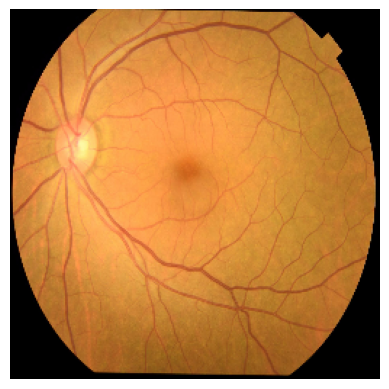

In [ ]:
img_healthy = folder + '/Data/Healthy/Healthy4.jpg'

show_image(img_healthy,255,255)

Visualizando imagem de fundo de olho de **retinopatia diabética**

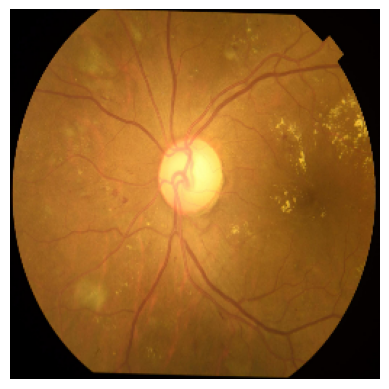

In [ ]:
img_retinopathy = folder + '/Data/Diabetic Retinopathy/DR103.jpg'

show_image(img_retinopathy,255,255)

##### **3.3. Pré-Processamento das Imagens**

###### **3.3.1. Máscara do Disco Óptico**

**Canal verde da imagem RGB**

< Explicação >

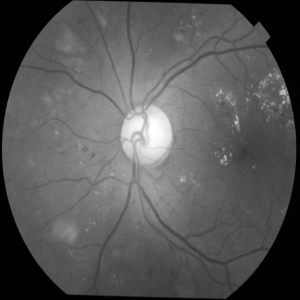

In [ ]:
# canal verde da imagem
img = cv.imread(img_retinopathy)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_resized = cv.resize(img_rgb, (300, 300), interpolation=cv.INTER_AREA)

R,G,B = cv.split(img_resized)

# resultado
cv2_imshow(G)

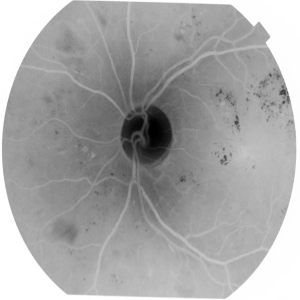

In [ ]:
# canal ciano
G_norm = G.astype(np.float32) / 255.0

img_cyan = 1.0 - G_norm

img_green_uint8 = (G_norm * 255).astype(np.uint8)
img_cyan_uint8 = (img_cyan * 255).astype(np.uint8)

cv2_imshow(img_cyan_uint8)

In [ ]:
# diferença absoluta (sem risco de overflow)
img_diff = cv.absdiff(img_green_uint8, img_cyan_uint8)

cv2_imshow(img_diff)

Binarização

In [ ]:
# metodo de otsu para simplificacao do disco optico
_, img_otsu = cv.threshold(img_diff, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

cv2_imshow(img_otsu)

In [ ]:
img_invertida = cv.bitwise_not(img_otsu)

cv2_imshow(img_invertida)

In [ ]:
img_shape = img_invertida.shape
img_shape

In [ ]:
img_crop = img_invertida[50:201, 50:201]
cv2_imshow(img_crop)

###### **3.3.2. Nervos Ópticos**

In [ ]:
# Leitura da imagem em RGB
img = cv.imread(img_retinopathy)
img_resized = cv.resize(img, (300, 300), interpolation=cv.INTER_AREA)
img_rgb = cv.cvtColor(img_resized, cv.COLOR_BGR2RGB)

# Normaliza [0,1] e converte para CMY (1 - RGB)
img_rgb_norm = img_rgb.astype(np.float32) / 255.0
img_cmy = 1.0 - img_rgb_norm

# Converte CMY para faixa [0,255] novamente
img_cmy = (img_cmy * 255).astype(np.uint8)

# Extrai canal Ciano (C)
cyan_channel = img_cmy[:, :, 0]

cv2_imshow(cyan_channel)

In [ ]:
# Kernel para morfologia
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))

# Erosão
erosion = cv.erode(cyan_channel, kernel, iterations=1)

# Abertura (erosão + dilatação)
opening = cv.morphologyEx(erosion, cv.MORPH_OPEN, kernel)

# Dilatação final
dilation = cv.dilate(opening, kernel, iterations=1)

In [ ]:
# Subtrai a imagem morfologicamente tratada da imagem original cyan
diff = cv.absdiff(cyan_channel, dilation)

diff_norm = cv.normalize(diff, None, 0, 255, cv.NORM_MINMAX)
diff_norm = diff_norm.astype(np.uint8)

In [ ]:
# Binarização com Otsu para realçar veias
_, binary = cv.threshold(diff_norm, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

In [ ]:
# Suavização final para eliminar ruído fino
smoothed = cv.GaussianBlur(binary, (5, 5), sigmaX=0)

In [ ]:
titles = ['Original RGB', 'Canal Ciano', 'Morfologia', 'Diferença', 'Binarizada', 'Gaussiano']
images = [img_rgb, cyan_channel, dilation, diff, binary, smoothed]

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    cmap = 'gray' if i > 0 else None
    plt.imshow(images[i], cmap=cmap)
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

##### **3.4. Simplificação das Imagens**

##### **3.5. Redes Neurais Convolucionais (CNNs)**

RESNET 34, 18, UNET + Efficient Net, Resnet50+UNET

###### **3.5.1. RESNET 34**

##### **3.6. Vision Transformer (ViT)**

< em andamento >

#### **4. Resultados**